The aim of this project is to implement Convolutional Neural Network to

---

classify CIFAR-10 Dataset.

# Part 1: Data PreProcessing
The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class.

Here are the classes in the dataset, as well as 10 random images from each:

![CIFAR-10](https://pbs.twimg.com/media/FM9dCwwXsAEIngn?format=png&name=small)

# 1. Import Libraries and Dataset

#### Check Working Directory

In [1]:
import os
os.getcwd()

'/kaggle/working'

#### Import Libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix

2025-05-03 13:55:44.384837: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746280544.586703      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746280544.646450      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### 1.1: Load the Dataset

In [3]:
from keras.datasets import cifar10

In [4]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


### 1.2: Data Preprocessing and Visualization

#### Data Visualization

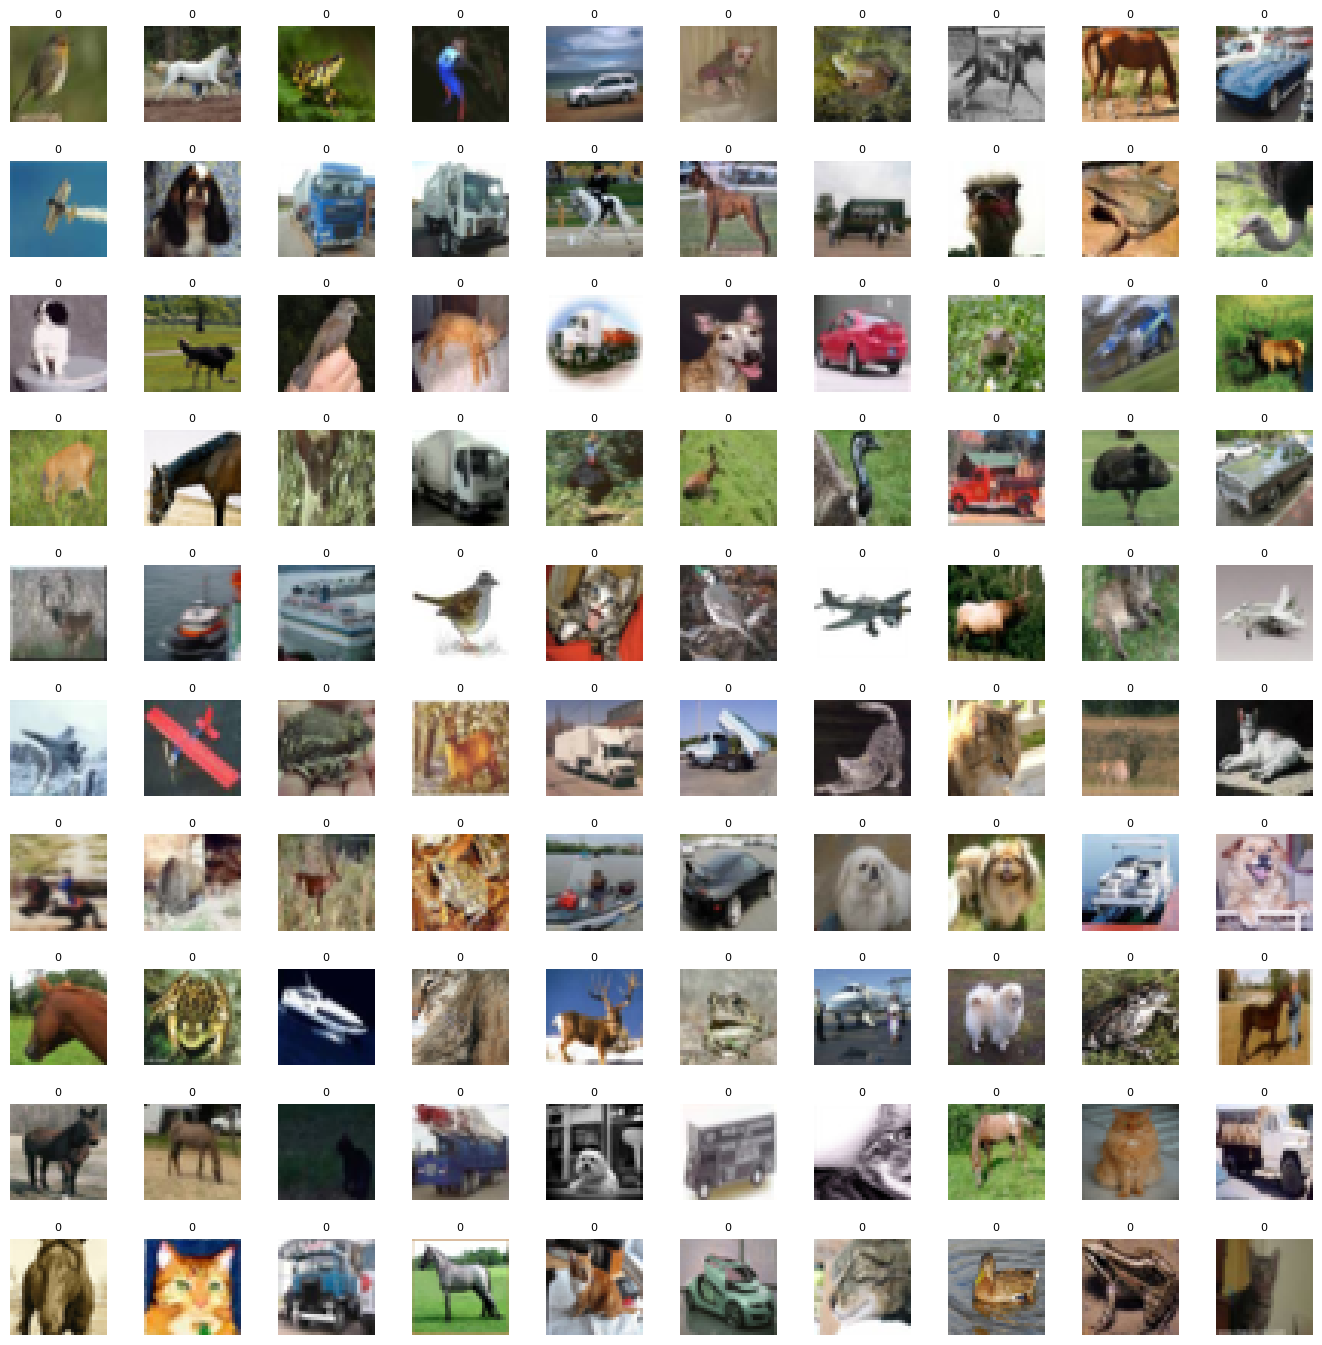

In [6]:
import matplotlib.pyplot as plt
import numpy as np

labels = [str(i) for i in range(10)]  # Update with actual class names if needed

W_grid = 10
L_grid = 10

fig, axes = plt.subplots(L_grid, W_grid, figsize=(17, 17))
axes = axes.ravel()

n_train = len(X_train)

for i in np.arange(0, W_grid * L_grid):
    index = np.random.randint(0, n_train)
    axes[i].imshow(X_train[index])  # Assuming shape is (32, 32, 3)
    label_index = np.argmax(y_train[index]) if y_train.ndim > 1 else y_train[index]
    axes[i].set_title(labels[label_index], fontsize=8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)
plt.show()


Text(0.5, 1.0, 'Class distribution in training set')

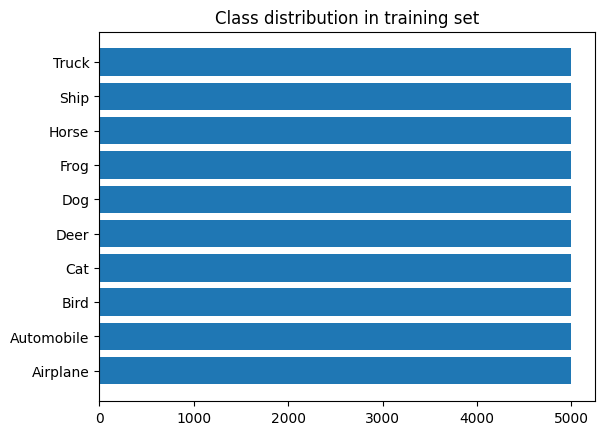

In [7]:
classes_name = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

classes, counts = np.unique(y_train, return_counts=True)
plt.barh(classes_name, counts)
plt.title('Class distribution in training set')

Text(0.5, 1.0, 'Class distribution in testing set')

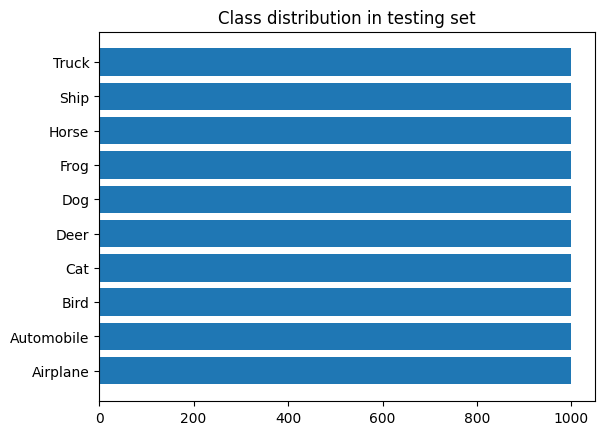

In [8]:
classes, counts = np.unique(y_test, return_counts=True)
plt.barh(classes_name, counts)
plt.title('Class distribution in testing set')

#### Data Preprocessing

In [9]:
# Scale the data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Transform target variable into one-hotencoding
y_cat_train = to_categorical(y_train, 10)
y_cat_test = to_categorical(y_test, 10)

In [10]:
y_cat_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

# Part 2: Build CNN Model

### 2.1: Implementation of Convolutional Neural network

In [17]:
model = Sequential()

# Convolutional Layer
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
# Pooling layer
model.add(MaxPool2D(pool_size=(2, 2)))
# Dropout layers
model.add(Dropout(0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters=128, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=(3, 3), input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
# model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10, activation='softmax'))

METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=METRICS)

#### Model Summary

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)

#### Early Stopping

In [19]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

### 2.2: Data Augmentations

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32
data_generator = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
train_generator = data_generator.flow(X_train, y_cat_train, batch_size=batch_size)

### 2.3:Fit the Data to Model

In [21]:
r = model.fit(
    train_generator,
    epochs=60,
    validation_data=(X_test, y_cat_test),
    # callbacks=[early_stop],  # Optional
)


Epoch 1/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.3234 - loss: 1.9136 - precision: 0.5133 - recall: 0.1127 - val_accuracy: 0.5053 - val_loss: 1.3754 - val_precision: 0.6816 - val_recall: 0.3677
Epoch 2/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.5243 - loss: 1.3257 - precision: 0.6996 - recall: 0.3429 - val_accuracy: 0.6688 - val_loss: 0.9486 - val_precision: 0.7861 - val_recall: 0.5511
Epoch 3/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6163 - loss: 1.0974 - precision: 0.7591 - recall: 0.4742 - val_accuracy: 0.6817 - val_loss: 0.9323 - val_precision: 0.7875 - val_recall: 0.5723
Epoch 4/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6684 - loss: 0.9662 - precision: 0.7884 - recall: 0.5483 - val_accuracy: 0.6861 - val_loss: 0.9234 - val_precision: 0.7610 - val_recall: 0.6146
Epoch 5/60
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6960 - loss: 0.8889 - precision: 0.8078 - recall: 0.5911 - val_accuracy: 0

# Part 3: Result Evaluation

### 3.1: Model Evaluation

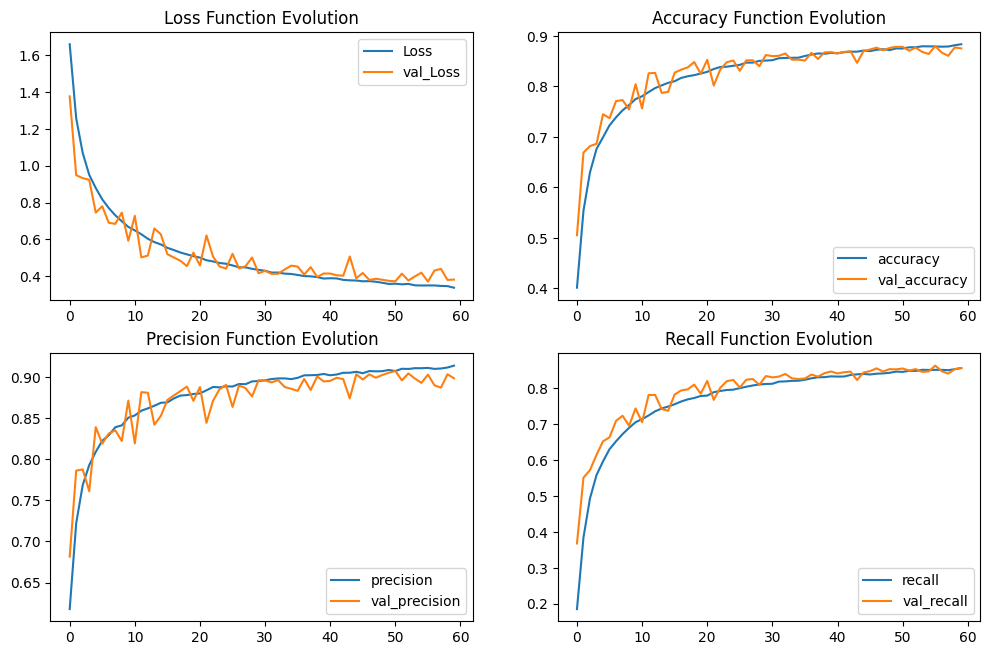

In [22]:
plt.figure(figsize=(12, 16))

plt.subplot(4, 2, 1)
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='val_Loss')
plt.title('Loss Function Evolution')
plt.legend()

plt.subplot(4, 2, 2)
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Function Evolution')
plt.legend()

plt.subplot(4, 2, 3)
plt.plot(r.history['precision'], label='precision')
plt.plot(r.history['val_precision'], label='val_precision')
plt.title('Precision Function Evolution')
plt.legend()

plt.subplot(4, 2, 4)
plt.plot(r.history['recall'], label='recall')
plt.plot(r.history['val_recall'], label='val_recall')
plt.title('Recall Function Evolution')
plt.legend()

In [23]:
evaluation = model.evaluate(X_test, y_cat_test)
print(f'Test Accuracy : {evaluation[1] * 100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8754 - loss: 0.3786 - precision: 0.8992 - recall: 0.8572
Test Accuracy : 87.50%


### 3.2:  Confusion Matrix

In [24]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
#y_test = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test, y_pred)
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
[[892   4  34  11   5   1   6   9  26  12]
 [  5 949   0   3   0   0   2   0   3  38]
 [ 36   1 850  25  19  15  44   4   4   2]
 [ 12   2  36 795  22  53  55  13   4   8]
 [  5   1  40  43 840   6  46  17   2   0]
 [  4   2  29 170  22 716  33  17   2   5]
 [  3   0  28  24   2   1 938   2   1   1]
 [  4   0  10  29  23  10   9 907   3   5]
 [ 43   8   5   5   1   0   2   0 917  19]
 [ 13  27   3   3   1   1   1   2   3 946]]


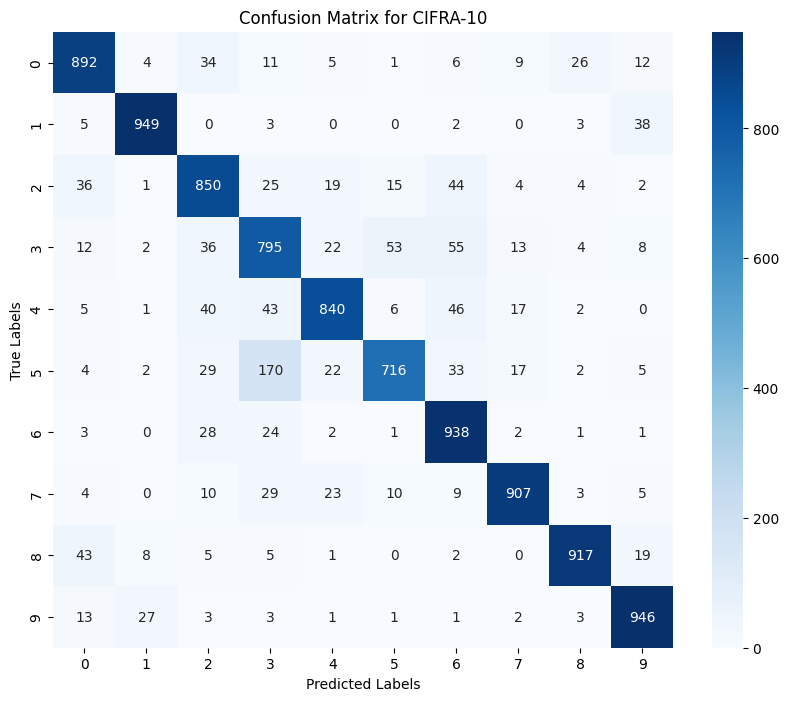

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn for annotated numbers
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for CIFRA-10')
plt.show()

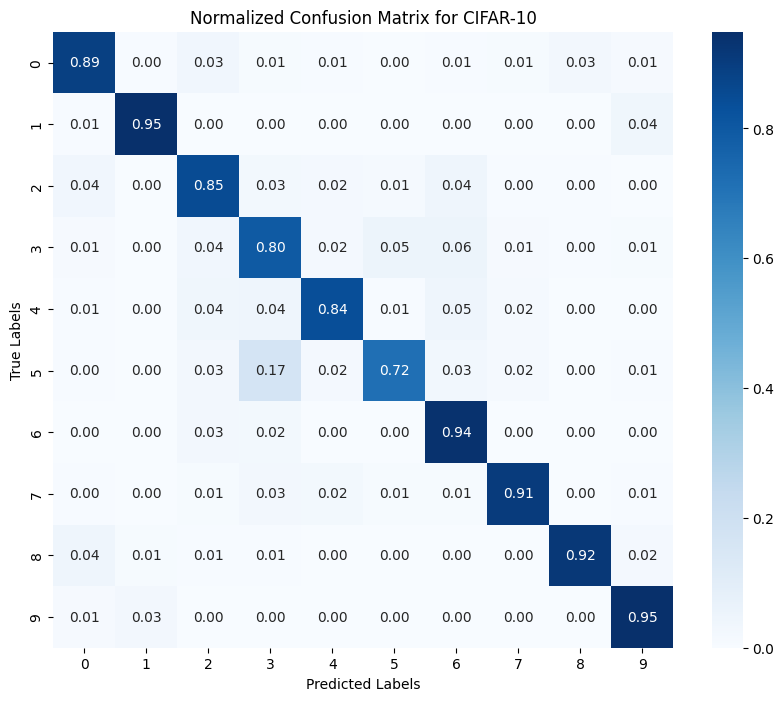

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize the confusion matrix (row-wise)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Normalized Confusion Matrix for CIFAR-10')
plt.show()


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88      1000
           1       0.95      0.95      0.95      1000
           2       0.82      0.85      0.84      1000
           3       0.72      0.80      0.75      1000
           4       0.90      0.84      0.87      1000
           5       0.89      0.72      0.79      1000
           6       0.83      0.94      0.88      1000
           7       0.93      0.91      0.92      1000
           8       0.95      0.92      0.93      1000
           9       0.91      0.95      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



### 3.3: Result Summary

## Part 4: Test Model on Images

### 4.1: Test on one Image

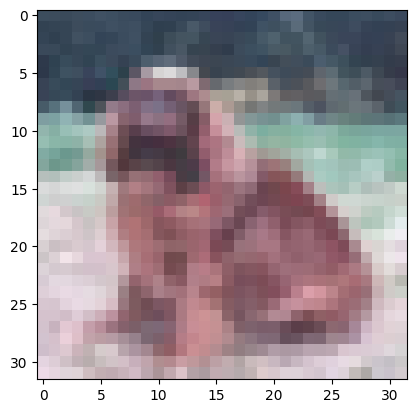

In [31]:
my_image = X_test[101]
plt.imshow(my_image)

In [32]:
# that's a Dog
y_test[101]

array([5], dtype=uint8)

In [33]:
# correctly predicted as a Dog
np.argmax(model.predict(my_image.reshape(1, 32, 32, 3)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step


5

### 4.2: Test on Multiple Images

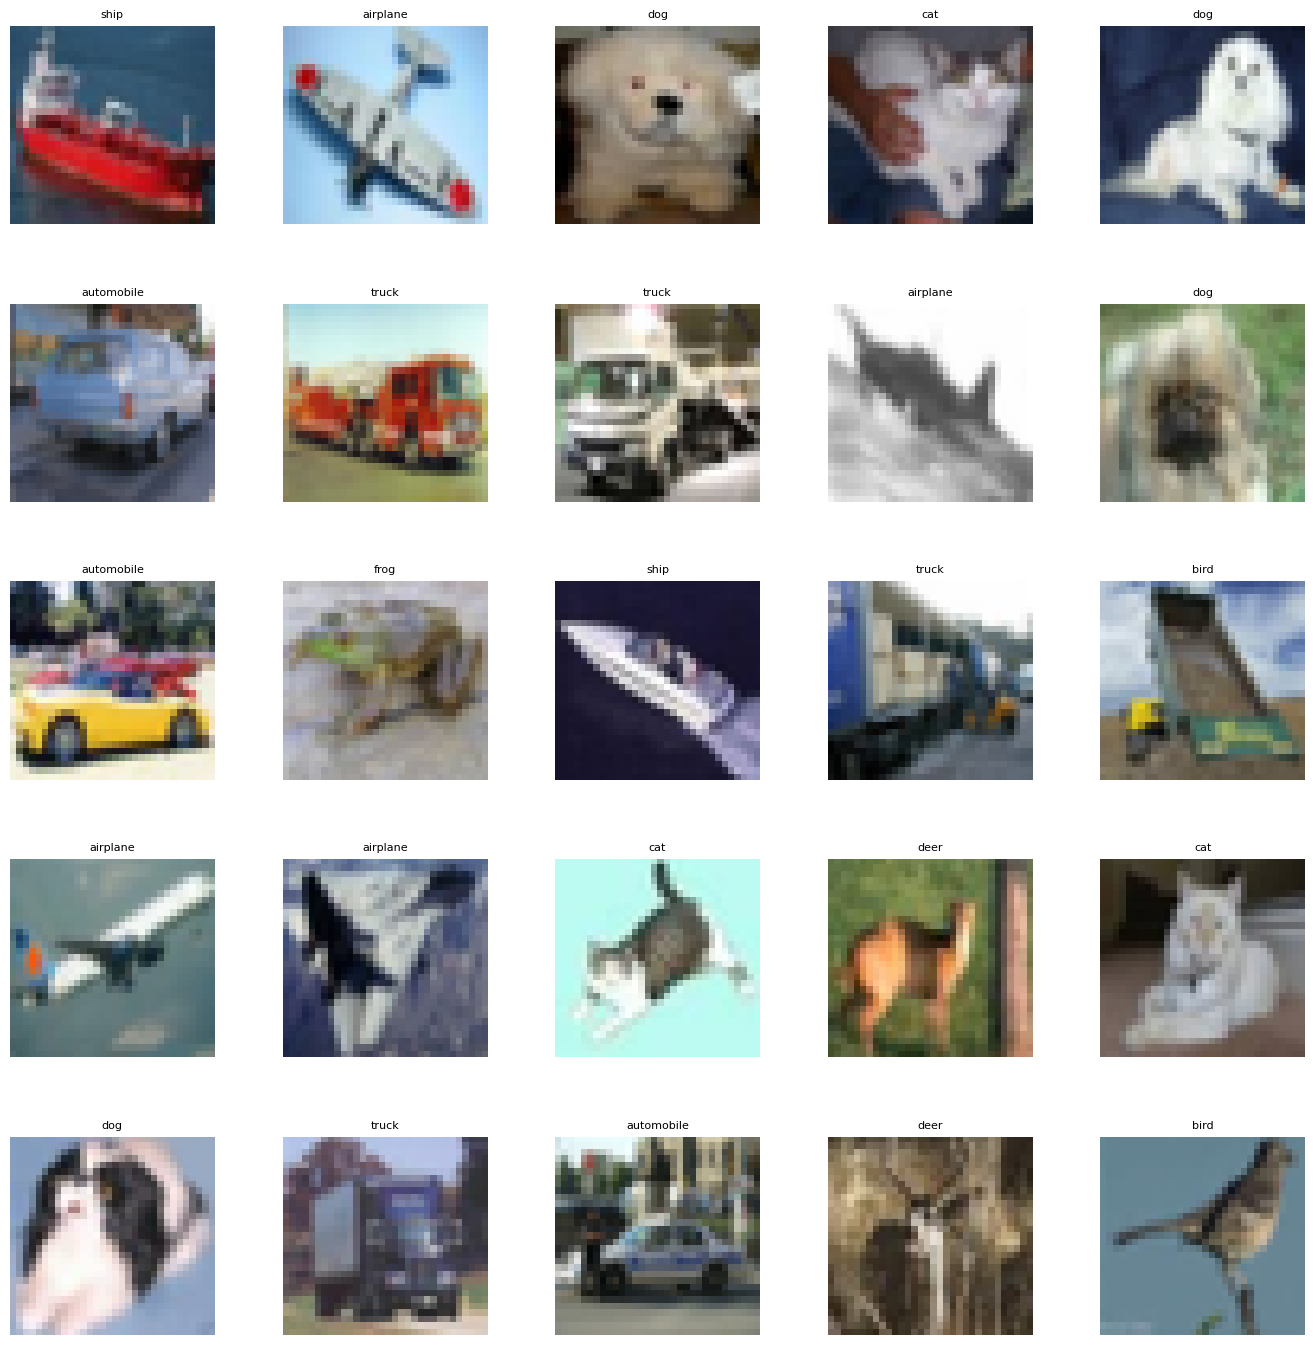

In [34]:
# Define the labels of the dataset
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck']

# Let's view more images in a grid format
# Define the dimensions of the plot grid
W_grid = 5
L_grid = 5

# fig, axes = plt.subplots(L_grid, W_grid)
# subplot return the figure object and axes object
# we can use the axes object to plot specific figures at various locations

fig, axes = plt.subplots(L_grid, W_grid, figsize = (17,17))

axes = axes.ravel() # flaten the 15 x 15 matrix into 225 array

n_test = len(X_test) # get the length of the train dataset

# Select a random number from 0 to n_train
for i in np.arange(0, W_grid * L_grid): # create evenly spaces variables

    # Select a random number
    index = np.random.randint(0, n_test)
    # read and display an image with the selected index
    axes[i].imshow(X_test[index,1:])
    label_index = int(y_pred[index])
    axes[i].set_title(labels[label_index], fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

In [35]:
predictions = model.predict(X_test)
print(predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[2.33533672e-08 1.12752986e-07 8.34491511e-05 ... 2.24748618e-07
  6.24837497e-08 3.33547878e-09]
 [1.58556122e-05 6.44188112e-05 5.21199403e-11 ... 4.70880481e-15
  9.99919415e-01 3.61714910e-07]
 [3.37722828e-04 3.10427451e-04 2.22265115e-07 ... 1.27468286e-10
  9.99349892e-01 1.58150181e-06]
 ...
 [8.23006078e-14 1.28606720e-13 3.92657375e-06 ... 8.86911788e-09
  4.20344402e-12 1.32179966e-12]
 [1.29058037e-03 9.79764879e-01 2.65772513e-04 ... 4.09661734e-05
  4.58409748e-04 1.58801395e-02]
 [4.67431998e-15 2.68083317e-19 1.63046974e-12 ... 9.99999881e-01
  1.28011576e-18 7.94188467e-16]]


In [36]:
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array, true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(f"{labels[int(predicted_label)]} {100*np.max(predictions_array):2.0f}% ({labels[int(true_label)]})",
               color=color)

def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array, int(true_label[i])
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

/tmp/ipykernel_31/215262446.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.xlabel(f"{labels[int(predicted_label)]} {100*np.max(predictions_array):2.0f}% ({labels[int(true_label)]})",
/tmp/ipykernel_31/215262446.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions_array, true_label = predictions_array, int(true_label[i])


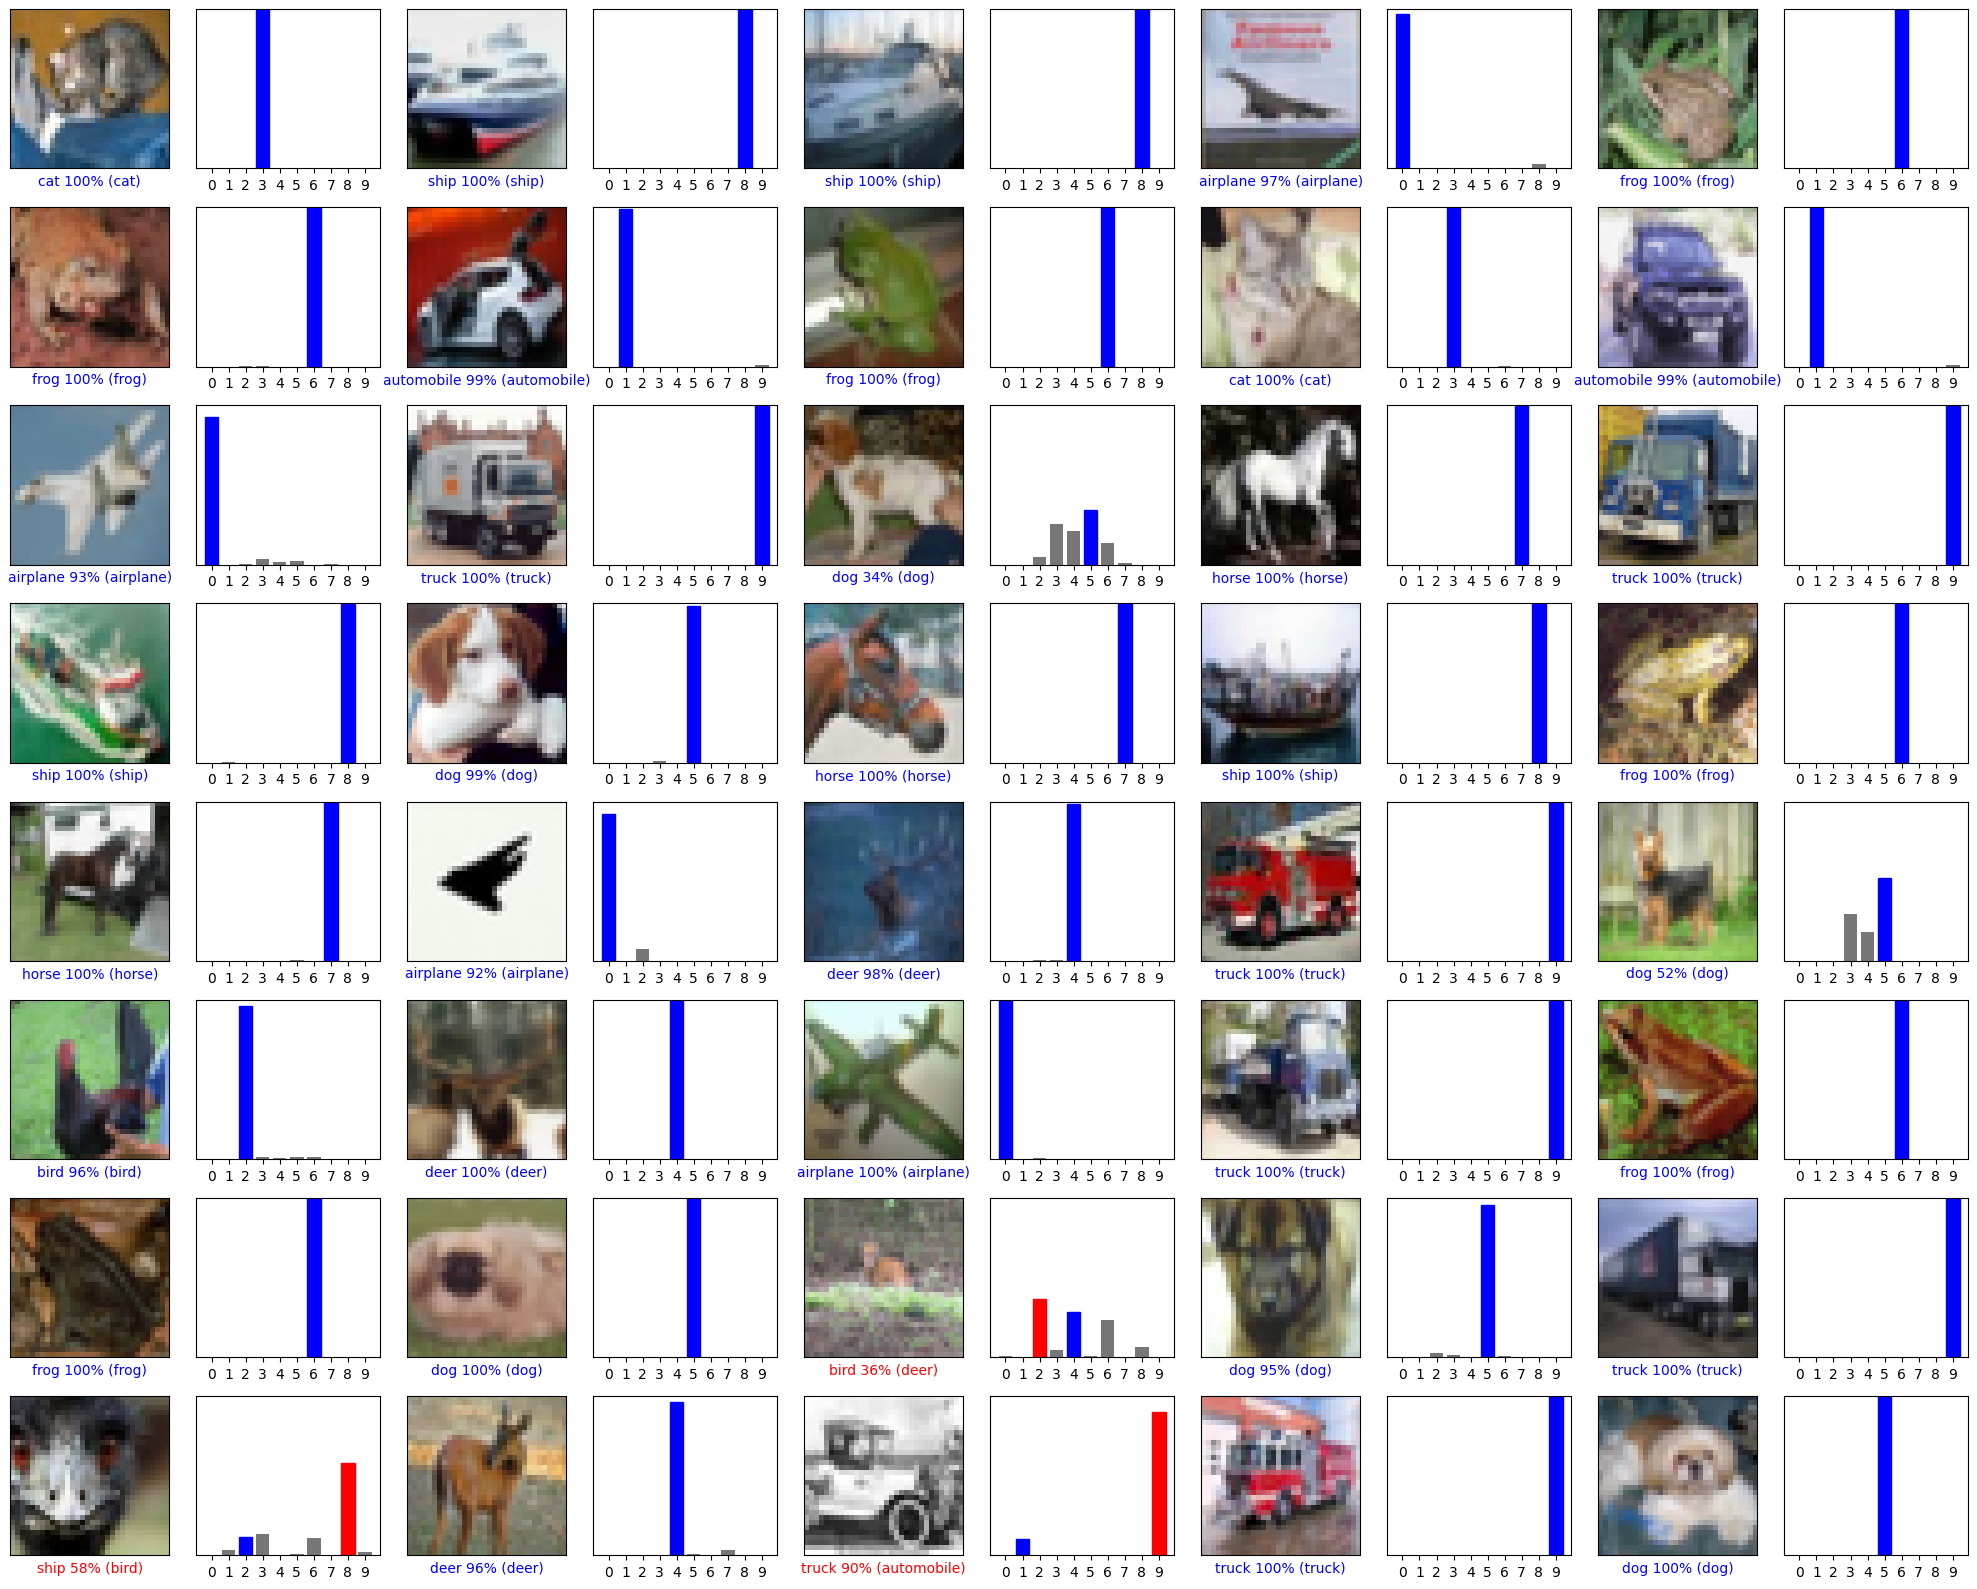

In [38]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 8
num_cols = 5
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions[i], y_test, X_test)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i], y_test)
plt.tight_layout()
plt.show()

In [45]:
# Save the Model
model.save("image_clasify_model.h5")

In [50]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from keras.models import load_model

# Load Keras model
keras_model = load_model('/kaggle/working/image_clasify_model.h5')
keras_weights = keras_model.get_weights()

# Define equivalent PyTorch model
class CIFARModel(nn.Module):
    def __init__(self):
        super(CIFARModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)

        self.conv5 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = self.dropout(x)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool(x)
        x = self.dropout(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Instantiate PyTorch model
model_torch = CIFARModel()

# Assign weights from Keras to PyTorch
def set_conv_weights(torch_layer, weight, bias):
    torch_layer.weight.data = torch.from_numpy(weight).permute(3, 2, 0, 1)
    torch_layer.bias.data = torch.from_numpy(bias)

def set_bn_weights(torch_bn, gamma, beta, mean, var):
    torch_bn.weight.data = torch.from_numpy(gamma)
    torch_bn.bias.data = torch.from_numpy(beta)
    torch_bn.running_mean.data = torch.from_numpy(mean)
    torch_bn.running_var.data = torch.from_numpy(var)

idx = 0
set_conv_weights(model_torch.conv1, keras_weights[idx], keras_weights[idx + 1]); idx += 2
set_bn_weights(model_torch.bn1, *keras_weights[idx:idx + 4]); idx += 4
set_conv_weights(model_torch.conv2, keras_weights[idx], keras_weights[idx + 1]); idx += 2
set_bn_weights(model_torch.bn2, *keras_weights[idx:idx + 4]); idx += 4
set_conv_weights(model_torch.conv3, keras_weights[idx], keras_weights[idx + 1]); idx += 2
set_bn_weights(model_torch.bn3, *keras_weights[idx:idx + 4]); idx += 4
set_conv_weights(model_torch.conv4, keras_weights[idx], keras_weights[idx + 1]); idx += 2
set_bn_weights(model_torch.bn4, *keras_weights[idx:idx + 4]); idx += 4
set_conv_weights(model_torch.conv5, keras_weights[idx], keras_weights[idx + 1]); idx += 2
set_bn_weights(model_torch.bn5, *keras_weights[idx:idx + 4]); idx += 4
set_conv_weights(model_torch.conv6, keras_weights[idx], keras_weights[idx + 1]); idx += 2
set_bn_weights(model_torch.bn6, *keras_weights[idx:idx + 4]); idx += 4

model_torch.fc1.weight.data = torch.from_numpy(keras_weights[idx].T); idx += 1
model_torch.fc1.bias.data = torch.from_numpy(keras_weights[idx]); idx += 1
model_torch.fc2.weight.data = torch.from_numpy(keras_weights[idx].T); idx += 1
model_torch.fc2.bias.data = torch.from_numpy(keras_weights[idx]); idx += 1

In [51]:
# Save the PyTorch model
torch.save(model_torch.state_dict(), 'CIFAR_Model.pt')
print("Model converted and saved as 'CIFAR_Model.pt'")

Model converted and saved as 'CIFAR_Model.pt'
